<a href="https://colab.research.google.com/github/muneeb0065/Machine-Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("Salary_Data.csv")

In [ ]:
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
x = data.iloc[:, 0:1]
y = data.iloc[:, 1:2]

In [ ]:
y

,Salary
0,39343
1,46205
2,37731
3,43525
4,39891
5,56642
6,60150
7,54445
8,64445
9,57189


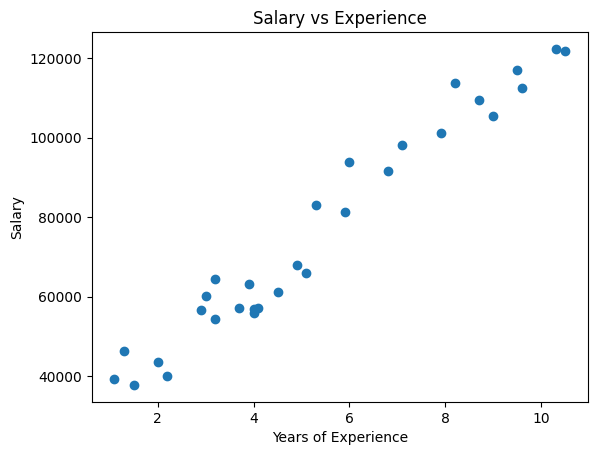

In [ ]:
plt.scatter(x,y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.show()

x and y are your feature (Years of Experience) and target (Salary) data, respectively.
test_size = 0.2 specifies that 20% of your data will be used for the testing set, and the remaining 80% will be used for the training set.
random_state = 0 is used to ensure reproducibility. If you run this code multiple times with the same random_state, you will get the same split every time. This is useful for debugging and comparing different models.


In [106]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

NameError: name 'x' is not defined

In [ ]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()

In [ ]:
LR.fit(x_train, y_train) # Finds the best fit line

LinearRegression()

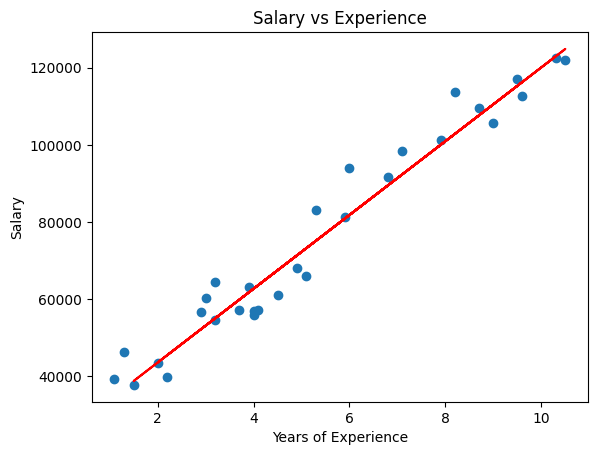

In [ ]:
plt.scatter(data["YearsExperience"], data["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.plot(x_train, LR.predict(x_train), color = "red")
plt.show()

In [ ]:
m = LR.coef_


In [ ]:
c = LR.intercept_

# **Now we are going to implement the Gradient Descent Algorithm for the Multiple Linear Regression where we have more than one input coloumn**
      

In [7]:
# load the dataset from the sciket learn library

from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [8]:
# Now put the data in X and y variables
X, y = load_diabetes(return_X_y=True)


In [111]:
print (X.shape)
print (y.shape)

(442, 10)
(442,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [113]:
reg = LinearRegression()
reg.fit(X_train, y_train)


LinearRegression()

In [114]:
print(reg.coef_)
print(reg.intercept_)


# we have used the sciket learn for checking the coef and then we will create our own class and check the difference

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [115]:
y_pred = reg.predict(X_test)
r2_score(y_test, y_pred)

0.4399338661568968

# Now we will create our class and calculate

In [10]:
class GDRegressor:

  def __init__ (self, learning_rate, epochs):
    self.lr= learning_rate
    self.epochs = epochs
    self.coef_= None
    self.intercept_= None


  def fit(self, X_train, y_train):
    # Now we initialize the intercept with 0 and all the coef with 1
    self.intercept_ = 0
    self.coef_ = np.ones(X_train.shape[1])

    # Now we will create a loop that will run the number of times our epochs are
    for i in range(self.epochs):

      # here we have to first change or update the value of intercept
      # Additional details are handwrtten on notebook.
      y_hat = np.dot(X_train , self.coef_ ) + self.intercept_
      intercept_derivative = -2 * np.mean(y_train - y_hat )
      self.intercept_ = self.intercept_ - (self.lr  * intercept_derivative)



      # Now as we update the value of all the coeficients similar like we calculate for the intercept
      coef_derivative = -2 * np.dot((y_train - y_hat) , X_train)/ X_train.shape[0] # here X_train.shape is all the number of rows
      self.coef_ = self.coef_ - (self.lr * coef_derivative)

    print(self.coef_ , self.intercept_)

  def predicet(self, X_test):
    return np.dot(X_test, self.coef_ ) + self.intercept_

In [143]:
# Now we will create the object of the class

gdr = GDRegressor(learning_rate= 0.4 , epochs= 1000)

In [144]:
gdr.fit(X_train, y_train)

[  23.72258115 -153.73159869  468.33623372  312.6634481   -29.57078448
 -101.98457793 -193.13547041  109.88215911  425.62365976  108.08959706] 152.04695545523967


In [120]:
y_pred = gdr.predicet(X_test)

In [121]:
r2_score(y_test, y_pred)

0.45392659741468355

** Now we are going to implement the stocastic gradient descent algorithm because when we have a lot of data then the batch gradient descent algorithm will be slow down because in batch gradient descent algorithm we have to calculate all the coef and then we will make one update and one larger datasets our algorithm will be much slower.**

** So we will use the stocastic gradient algorithm where we randomly select row in the dataset then update our coef and intercept based on that data point**

**Another benefit of stocastic gradient algorithm is that if we dont have a convex function and we have one or more local minima and in that case the stocastic algo can make an jump even after reaching the local minima and then it will find the golbal minima.**

In [11]:
class SGDRegressor:

  def __init__ (self, learning_rate, epochs):
    self.lr= learning_rate
    self.epochs = epochs
    self.coef_= None
    self.intercept_= None


  def fit(self, X_train, y_train):
    # Now we initialize the intercept with 0 and all the coef with 1
    self.intercept_ = 0
    self.coef_ = np.ones(X_train.shape[1])

    # Now we will create a loop that will run the number of times our epochs are
    for i in range(self.epochs):
      for j in range(self.X_train[0]):
        idx= np.random.randint(1, X_train[0])

      # here we have to first change or update the value of intercept
      # Additional details are handwrtten on notebook.

        y_hat = np.dot(X_train[idx] , self.coef_ ) + self.intercept_
        intercept_derivative = -2 * (y_train[idx] - y_hat )
        self.intercept_ = self.intercept_ - (self.lr  * intercept_derivative)


      # Now as we update the value of all the coeficients similar like we calculate for the intercept
        coef_derivative = -2 * np.dot((y_train[idx] - y_hat) , X_train[idx]) # here X_train.shape is all the number of rows
        self.coef_ = self.coef_ - (self.lr * coef_derivative)

    print(self.coef_ , self.intercept_)

  def predicet(self, X_test):
    return np.dot(X_test, self.coef_ ) + self.intercept_

In [169]:
# Now we will create the object of the class

sgd = SGDRegressor(learning_rate= 0.02 , epochs= 50)

In [170]:
gdr.fit(X_train, y_train)

[  23.72258115 -153.73159869  468.33623372  312.6634481   -29.57078448
 -101.98457793 -193.13547041  109.88215911  425.62365976  108.08959706] 152.04695545523967


In [171]:
y_pred = gdr.predicet(X_test)

In [172]:
r2_score(y_test, y_pred)

0.45392659741468355

Now we are implementing the mini batch gradient descent algo because

Pure SGD forces Python to loop row-by-row, which creates massive language overhead. Pure BGD crashes on massive datasets.

The industry standard is Mini-Batch Gradient Descent:
Split the dataset into small chunks (e.g., batch size = 32, 64, or 256).
Process the chunk in parallel using optimized matrix math (fast hardware utilization).
Update the weights immediately after each chunk

In [32]:
import random
class MBGDRegressor:

  def __init__ (self,batch_size, learning_rate, epochs):
    self.batch_size = batch_size
    self.lr= learning_rate
    self.epochs = epochs
    self.coef_= None
    self.intercept_= None


  def fit(self, X_train, y_train):
    # Now we initialize the intercept with 0 and all the coef with 1
    self.intercept_ = 0
    self.coef_ = np.ones(X_train.shape[1])

    # Now we will create a loop that will run the number of times our epochs are
    for i in range(self.epochs):
      for j in range(int(X_train.shape[0])//self.batch_size):

        idx= random.sample(range(X_train.shape[0]), self.batch_size) #Here this is a function of ramdon library to generate more than one random numbers.

      # here we have to first change or update the value of intercept
      # Additional details are handwrtten on notebook.

        y_hat = np.dot(X_train[idx] , self.coef_ ) + self.intercept_
        intercept_derivative = -2 * np.mean(y_train[idx] - y_hat )
        self.intercept_ = self.intercept_ - (self.lr  * intercept_derivative)


      # Now as we update the value of all the coeficients similar like we calculate for the intercept
        coef_derivative = -2 * np.dot((y_train[idx] - y_hat) , X_train[idx]) / self.batch_size # here X_train.shape is all the number of rows
        self.coef_ = self.coef_ - (self.lr * coef_derivative)

    print(self.coef_ , self.intercept_)

  def predicet(self, X_test):
    return np.dot(X_test, self.coef_ ) + self.intercept_

In [46]:
mbgdr = MBGDRegressor(batch_size=int(X_train.shape[0]/50 ), learning_rate = 0.1, epochs= 100)
# here we divide the rows in 10 equal parts to that is our batch size


In [47]:
mbgdr.fit(X_train, y_train)

[  22.63045535 -158.80152207  487.20851573  318.0335039   -44.50058241
 -117.48469427 -193.39271447  104.88757629  444.34345781   93.2541757 ] 151.32641771149923


In [48]:
y_pred = mbgdr.predicet(X_test)

In [49]:
r2_score(y_test, y_pred)

0.4524307932072107